In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns

In [2]:
outputs_dir = '/n/tambe_lab/Everyone/model_output/subsetted_train_sites'
outputs_dir_rf = '/n/tambe_lab/Everyone/tree_mapping/model_output/subsetted_training_sets'
resolution=10
project_dir = '..'
lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_{resolution}m'

random_trial_seeds = np.arange(10)
split_seed = 10
pred_padding = 40

In [6]:
for model_type in [ 'rf_12_channel', 'fcn',  'pretrain_xception']:
    if model_type == 'fcn':
        channels = 12
        outputs_dir = f'/n/tambe_lab/Everyone/tree_mapping/model_output/local_only_models/128_filters/12_channels'
    elif model_type == 'rf_12_channel':
        channels = 12
        outputs_dir = '/n/tambe_lab/Everyone/tree_mapping/model_output/random_forest/12_channels'
    elif model_type == 'pretrained_xception':
        channels = 12
        outputs_dir = f'/n/tambe_lab/Everyone/tree_mapping/model_output/finetune_xceptionS2/pretrained/3_layers_tuned'
   
    models_num_sites = ['']
    df_rows = []

    results_by_site = {x: {} for x in models_num_sites}
    results_aggregated = {x: {} for x in models_num_sites}
    results_by_split = {x: {} for x in models_num_sites}

    for model in models_num_sites:
        for n_train_sites in [3,6,9,12]:
            for seed in random_trial_seeds:
                labels = []
                preds = []
                model_output_dir = f'{outputs_dir}/{n_train_sites}_train_sites/seed_{seed}'

                for split_number in np.arange(4):
                    labels_by_split = []
                    preds_by_split = []
                    test_sites = get_site_splits(split_seed, data_dir = '../data')[split_number]['test_sites']
                    for site in test_sites:
                        with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                            site_labels = file.read().ravel()
                            labels = np.append(labels, site_labels)
                            labels_by_split = np.append(labels_by_split, site_labels)

                        with rasterio.open(f'{model_output_dir}/preds_{site}.tif') as file: # opens prediction tiff
                            site_preds = file.read()[:,pred_padding:-pred_padding,pred_padding:-pred_padding].ravel()
                            preds = np.append(preds, site_preds)
                            preds_by_split = np.append(preds_by_split, site_preds)

                        results_by_site[model][site] = compare_aligned_data(site_labels, site_preds)
                    res_dict = compare_aligned_data(labels_by_split, preds_by_split)
                    results_by_split[model][split_number] = res_dict 
                    res_dict.pop('errors') # dont need this for df
                    this_row = {'model':model, 'seed': seed, 'num_train_sites': n_train_sites, 'split': split_number, 'channel':channels}
                    this_row.update(res_dict)

                    df_rows.append(this_row)

                results_aggregated[model] = compare_aligned_data(labels, preds)

    #save this as a CSV for loading later
    results_by_num_splits = pd.DataFrame(df_rows)
    results_by_num_splits.to_csv(f'../experiment_results/results_by_num_training_sites_{model_type}.csv')

# 1. get the data for different number of training sites


In [7]:
results_keys = ['r2','mae','mse','rmse']

results_by_model = {}
for model_type in ['fcn', 'rf_12_channel', 'pretrained_xception']:
# load the CSV we just made
    results_by_num_sites_df= pd.read_csv(f'../experiment_results/results_by_num_training_sites_{model_type}.csv')
    results_by_model[model_type.lower()] = results_by_num_sites_df.rename(columns={'split':'test_split', 'layers':'num_image_layers_used'})


/tmp/ipykernel_1404081/3331387707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_this_split.loc[:,'less_than_reference'] = (df_this_split.loc[:,plot_key] < reference).values
/tmp/ipykernel_1404081/3331387707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_this_split.loc[:,'less_than_reference'] = (df_this_split.loc[:,plot_key] < reference).values
/tmp/ipykernel_1404081/3331387707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

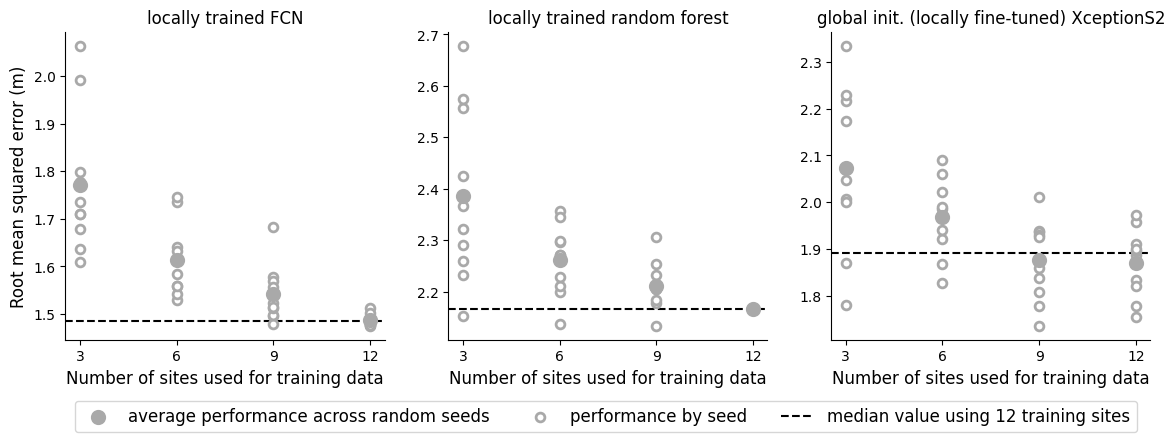

In [8]:
plot_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

fig, ax = plt.subplots(1,3,figsize=(14,4),sharey=False)

aggregate_all = pd.DataFrame()

for j, (model_type, model_name, color) in enumerate([('fcn', 'locally trained FCN', 'forestgreen'), 
                                              ('rf_12_channel', 'locally trained random forest', 'forestgreen'),
                                              ('pretrained_xception', 'global init. (locally fine-tuned) XceptionS2', 'darkblue'),
                                            #  ('unet', 'locally fine-tuned (globally init.) U-Net'), 
                                              ]):
    count_num_better = pd.DataFrame()
    results_by_num_sites_df = results_by_model[model_type]
    
    for i in range(4):
        
        df_this_split = results_by_num_sites_df.loc[results_by_num_sites_df.loc[:,'test_split']==i]
        reference = df_this_split.loc[df_this_split.loc[:,'num_train_sites']==12,plot_key].median()
        df_this_split.loc[:,'less_than_reference'] = (df_this_split.loc[:,plot_key] < reference).values
        
        if i == 0:
            sns.scatterplot(data=df_this_split.groupby('num_train_sites').mean(), x='num_train_sites', y=plot_key, ax=ax[j], 
                            color='darkgrey',
                            edgecolor='darkgrey',
                            label='average performance across random seeds',
                            linewidth=2,
                            s=80,
                            zorder=2
                            )
            
            sns.scatterplot(data=df_this_split, x='num_train_sites', y=plot_key, ax=ax[j], 
                            linewidth=2,
                            s=40,
                            edgecolor='darkgrey', 
                            facecolor='white',
                            label='performance by seed')
            

            ax[j].set_title(model_name)
            ax[j].axhline(reference, color='black', ls = '--', zorder=-1, label='median value using 12 training sites')
            ax[j].set_xticks([3,6,9,12])
        
        count_better_this_split = pd.DataFrame(df_this_split.groupby(['num_train_sites'])['less_than_reference'].sum())

        count_better_this_split = count_better_this_split.rename(columns={'less_than_reference':f'split {i}'})
        
        if i == 0: count_num_better = count_better_this_split    
        else: count_num_better = pd.merge(count_num_better, count_better_this_split, on='num_train_sites', how='outer')

        
    count_num_better.loc[:,'model'] = model_type
    count_num_better.loc[:,'avg'] = count_num_better[[f'split {x}' for x in range(4)]].mean(axis=1).values
    aggregate_all = pd.concat((aggregate_all, count_num_better))
    
    if j == 0: 
        ax[j].legend(ncols=3, loc= (.03,-.3), fontsize='large')    
        ax[j].set_ylabel(metric_labels[plot_key])
    else:
        ax[j].get_legend().remove()
        ax[j].set_ylabel('')
    
for ax_this in ax: ax_this.set_xlabel('Number of sites used for training data', fontsize='large')    
ax[0].set_ylabel('Root mean squared error (m)', fontsize='large')    
sns.despine()

plt.savefig('../figures/data_model_interactions.png', bbox_inches='tight')

In [10]:
results_by_num_sites_df = results_by_model['fcn']
    
for i in range(1):
    df_this_split = results_by_num_sites_df.loc[results_by_num_sites_df.loc[:,'test_split']==i]
    df_this_split.groupby('num_train_sites').mean()

In [11]:
df_this_split = results_by_num_sites_df.loc[results_by_num_sites_df.loc[:,'test_split']==0]
df_this_split.groupby('num_train_sites').mean()

,Unnamed: 0,model,seed,test_split,channel,r2,mae,mse,rmse,me,perc_10,q1,median,q3,perc_90,perc_10_abs,q1_abs,median_abs,q3_abs,perc_90_abs
num_train_sites,,,,,,,,,,,,,,,,,,,,
3,18.0,NaN,4.5,0.0,12.0,0.408697,1.369823,3.156871,1.771221,-0.046334,-2.417674,-1.060428,0.163470,1.099655,1.909233,0.210467,0.528907,1.104856,1.913789,2.887654
6,58.0,NaN,4.5,0.0,12.0,0.510974,1.232888,2.610832,1.614174,0.000949,-2.114354,-0.907750,0.166672,0.998759,1.785625,0.183625,0.461388,0.971861,1.722860,2.628535
9,98.0,NaN,4.5,0.0,12.0,0.554513,1.166199,2.378381,1.541149,0.017306,-1.978508,-0.829793,0.169203,0.940530,1.714190,0.169773,0.427420,0.904315,1.622164,2.510287
12,138.0,NaN,4.5,0.0,12.0,0.586101,1.113348,2.209740,1.486478,0.029791,-1.869651,-0.776707,0.163282,0.892918,1.674148,0.157878,0.398083,0.847418,1.545779,2.418358


In [12]:
df_this_split = results_by_num_sites_df.loc[results_by_num_sites_df.loc[:,'test_split']==1]
df_this_split.groupby('num_train_sites').mean()

,Unnamed: 0,model,seed,test_split,channel,r2,mae,mse,rmse,me,perc_10,q1,median,q3,perc_90,perc_10_abs,q1_abs,median_abs,q3_abs,perc_90_abs
num_train_sites,,,,,,,,,,,,,,,,,,,,
3,19.0,NaN,4.5,1.0,12.0,0.411956,1.280184,2.873286,1.692996,0.026957,-2.064558,-0.914501,0.124588,1.050623,1.949156,0.179643,0.459620,1.002068,1.798401,2.728549
6,59.0,NaN,4.5,1.0,12.0,0.485529,1.177595,2.513793,1.584883,-0.029475,-1.966998,-0.893863,0.040983,0.895211,1.754866,0.158319,0.406885,0.899191,1.634213,2.538646
9,99.0,NaN,4.5,1.0,12.0,0.506782,1.147772,2.409951,1.552237,-0.012556,-1.920871,-0.856572,0.087734,0.870930,1.696785,0.155873,0.397019,0.866015,1.583965,2.490346
12,139.0,NaN,4.5,1.0,12.0,0.522514,1.122268,2.333081,1.527401,-0.030896,-1.902436,-0.850083,0.062391,0.826000,1.648462,0.147020,0.377680,0.837960,1.551009,2.452978


/tmp/ipykernel_1404081/1752372605.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_this_split.loc[:,'less_than_reference'] = (df_this_split.loc[:,plot_key] < reference).values
/tmp/ipykernel_1404081/1752372605.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_this_split.loc[:,'less_than_reference'] = (df_this_split.loc[:,plot_key] < reference).values
/n/home10/erolf/.conda/envs/tree_mapping/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecat

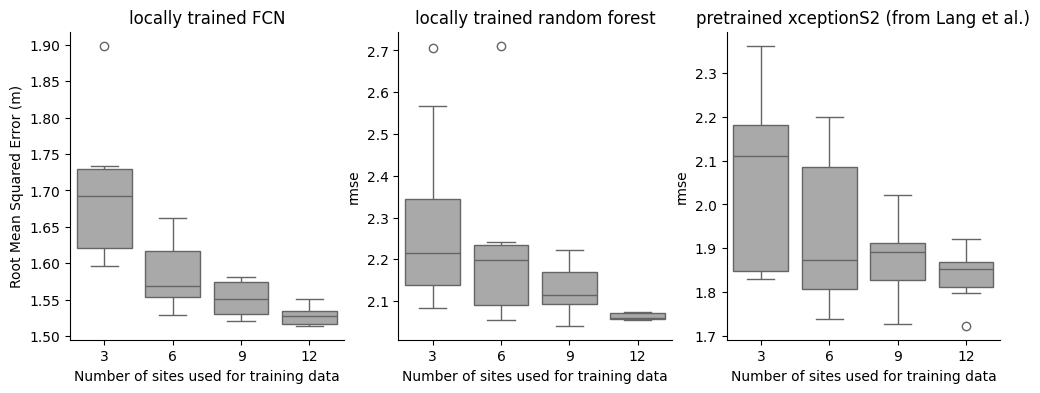

In [13]:
plot_key = 'rmse'
metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

fig, ax = plt.subplots(1,3,figsize=(12,4),sharey=False)

aggregate_all = pd.DataFrame()

for j, (model_type, model_name) in enumerate([('fcn', 'locally trained FCN'), 
                                              ('rf_12_channel', 'locally trained random forest'),
                                              ('pretrained_xception', 'pretrained xceptionS2 (from Lang et al.)'),
                                              ]):
    count_num_better = pd.DataFrame()
    results_by_num_sites_df = results_by_model[model_type]
    
    for i in range(4):
        
        df_this_split = results_by_num_sites_df.loc[results_by_num_sites_df.loc[:,'test_split']==i]
        reference = df_this_split.loc[df_this_split.loc[:,'num_train_sites']==12,plot_key].min()
        df_this_split.loc[:,'less_than_reference'] = (df_this_split.loc[:,plot_key] < reference).values
        
        if i == 1:
            sns.boxplot(data=df_this_split, x='num_train_sites', y=plot_key, ax=ax[j], color='darkgrey')
         #   sns.scatterplot(data=df_this_split[df_this_split[plot_key] <= reference], x='num_train_sites', y=plot_key, ax=ax[j], color='black')
            ax[j].set_title(model_name)
       #     ax[j].axhline(reference, color='black', ls = '--', zorder=-1)
ax[0].set_ylabel(metric_labels[plot_key])
for ax_this in ax: ax_this.set_xlabel('Number of sites used for training data')    
sns.despine()